In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.model_selection import cross_val_score
import platform

# 1. 변수 선택

수요예측 모델의 성능은 어떤 변수를 입력으로 사용하느냐에 크게 좌우된다.

외생변수(기상·경제·사회) 중 실제로 매출수량에 유의한 영향을 주는 변수만 선별하기 위해, 변

상관분석과 t-test를 통해 통계적으로 유의한 변수를 선별하고, 

의사결정나무를 활용해 Feature Importance를 산출하고, 이를 1(100%)로 정규화하여 비교하려한다.

| 분석 방법 | 대상 변수 유형 | 판단 기준 |
|-----------|--------------|-----------|
| 상관분석 | 연속형 변수 | \|r\| ≥ 0.3 |
| T-test | 이진형 변수 (COVID_19, 명절) | p-value < 0.05 |
| 의사결정나무 | 전체 변수 | 평균 이상 Feature Importance |

In [2]:
import os
save_dir = "/Users/danha/Desktop/IT/project/공모전/공모전/raw"
print(os.listdir(save_dir))

['.DS_Store', 'dataModel A - EA.csv', 'dataModel C - EA + 외생변수.csv', 'dataModel B - EA + 보정.csv', 'datascaled.csv', 'data']


In [3]:
# 한글 폰트
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    import subprocess
    subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
    fm._load_fontmanager(try_read_cache=False)
    nanum = [f for f in fm.findSystemFonts() if 'Nanum' in f]
    if nanum:
        plt.rcParams['font.family'] = fm.FontProperties(fname=nanum[0]).get_name()
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
save_dir = "/Users/danha/Desktop/IT/project/공모전/공모전/raw"
file_name = "datascaled.csv"

full_path = os.path.join(save_dir, file_name)

print("읽는 경로:", full_path)
df_final = pd.read_csv(full_path, encoding="utf-8-sig")

df_final['연월'] = pd.to_datetime(df_final['연월'])

print("Shape:", df_final.shape)
print("Columns:", df_final.columns.tolist())
display(df_final.head(4))


읽는 경로: /Users/danha/Desktop/IT/project/공모전/공모전/raw/datascaled.csv
Shape: (96, 14)
Columns: ['연월', '매입수량', '매출수량', '품목', '폭염일수', '한파일수', '평균기온', '평균일교차', '강수량', 'CPI_라면', 'CPI_탄산', 'COVID_19', '명절', '품목_코드']


,연월,매입수량,매출수량,품목,폭염일수,한파일수,평균기온,평균일교차,강수량,CPI_라면,CPI_탄산,COVID_19,명절,품목_코드
0,2021-01-01,0.638840,0.084777,봉지라면,0.0,1.000000,0.010239,0.583333,0.034359,0.024813,0.043699,1,0,0
1,2021-02-01,0.471567,0.023183,봉지라면,0.0,0.072727,0.163823,0.694444,0.034757,0.019299,0.076631,1,1,0
2,2021-03-01,0.848656,0.093270,봉지라면,0.0,0.000000,0.344710,0.708333,0.214697,0.025601,0.135529,1,0,0
3,2021-04-01,0.739345,0.043536,봉지라면,0.0,0.000000,0.498294,0.750000,0.146375,0.000000,0.210893,1,0,0


# 2. 상관분석

기상·경제 변수(평균기온, 강수량, CPI 등)는 연속형 변수이므로, 매출수량과의 선형적 관계를 파악하기위해 피어슨 상관계수로 파악하려한다.

상관계수 r은 -1 ~ 1 사이의 값을 가지며, 절댓값이 클수록 매출수량과의 연관성이 강하다는 것을 의미한다. 

단, 상관분석은 선형 관계만 포착하므로, 비선형 패턴이 있을 수 있는 변수는 의사결정나무 결과와 교차 검토한다.


- **|r| ≥ 0.5**: 강한 상관
- **0.3 ≤ |r| < 0.5**: 중간 상관  
- **|r| < 0.3**: 약한 상관


In [4]:
cont_vars = ['평균기온', '평균일교차', '강수량',
             '폭염일수', '한파일수', 'CPI_라면', 'CPI_탄산']

results = []
for 품목 in ['봉지라면', '탄산음료']:
    sub = df_final[df_final['품목'] == 품목].copy()
    for var in cont_vars:
        if var not in sub.columns:
            continue
        r, p = stats.pearsonr(sub[var].dropna(), sub['매출수량'].loc[sub[var].dropna().index])
        results.append({'품목': 품목, '변수': var, 'r': round(r, 4), 'p-value': round(p, 4),
                        '유의성': '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))})

corr_df = pd.DataFrame(results)
display(corr_df)


,품목,변수,r,p-value,유의성
0,봉지라면,평균기온,-0.2162,0.1400,
1,봉지라면,평균일교차,0.1063,0.4722,
2,봉지라면,강수량,-0.0845,0.5679,
3,봉지라면,폭염일수,-0.2087,0.1545,
4,봉지라면,한파일수,0.2381,0.1031,
5,봉지라면,CPI_라면,-0.3813,0.0075,**
6,봉지라면,CPI_탄산,-0.3309,0.0216,*
7,탄산음료,평균기온,0.6133,0.0000,***
8,탄산음료,평균일교차,-0.1533,0.2982,
9,탄산음료,강수량,0.3328,0.0208,*


## 2.1 상관분석 시각화


평균기온, 강수량 등 기상 변수가 탄산음료에는 어느 정도 유의한 상관을 보였고,

봉지라면은 CPI나 계절적 패턴의 영향이 더 큰 것으로 나타났다.

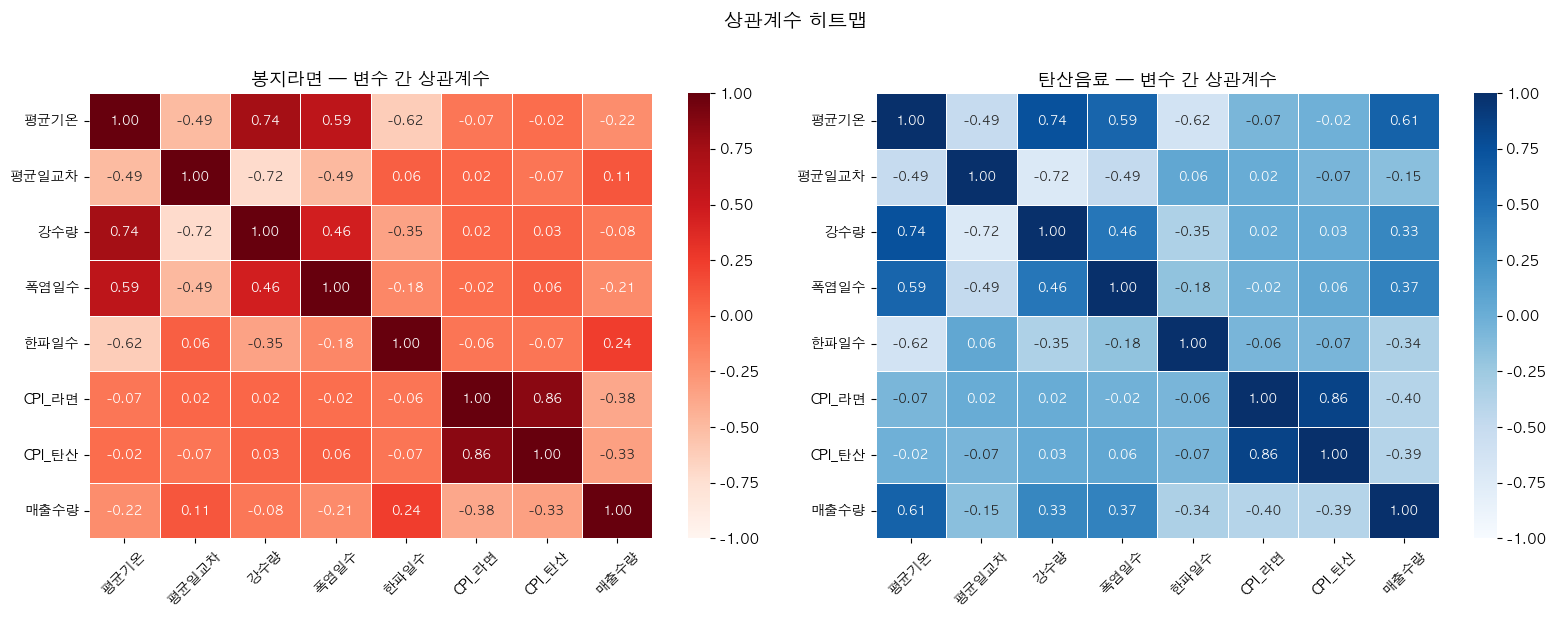

In [5]:
# 상관계수 히트맵
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (품목, color) in zip(axes, [('봉지라면', 'Reds'), ('탄산음료', 'Blues')]):
    sub = df_final[df_final['품목'] == 품목][cont_vars + ['매출수량']].dropna()
    corr_matrix = sub.corr()

    mask = np.zeros_like(corr_matrix, dtype=bool)
    mask[np.triu_indices_from(mask, k=1)] = True

    sns.heatmap(corr_matrix, ax=ax, annot=True, fmt='.2f', cmap=color,
                center=0, vmin=-1, vmax=1, linewidths=0.5,
                annot_kws={'size': 9})
    ax.set_title(f'{품목} — 변수 간 상관계수', fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('상관계수 히트맵', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


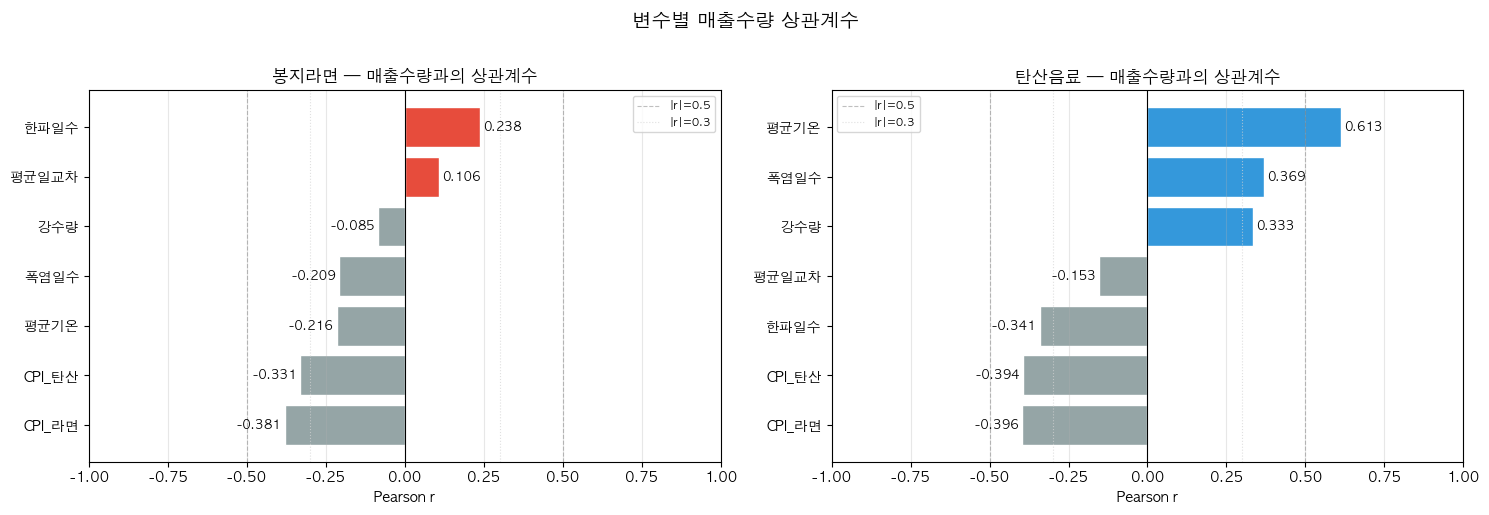

In [6]:
# 상관계수 바 차트
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (품목, color) in zip(axes, [('봉지라면', '#e74c3c'), ('탄산음료', '#3498db')]):
    sub_corr = corr_df[corr_df['품목'] == 품목].set_index('변수')['r'].sort_values()
    colors   = [color if v >= 0 else '#95a5a6' for v in sub_corr]
    bars     = ax.barh(sub_corr.index, sub_corr.values, color=colors, edgecolor='white')

    for bar, val in zip(bars, sub_corr.values):
        ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

    ax.axvline(0, color='black', linewidth=0.8)
    ax.axvline( 0.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.5, label='|r|=0.5')
    ax.axvline(-0.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axvline( 0.3, color='lightgray', linewidth=0.8, linestyle=':', alpha=0.7, label='|r|=0.3')
    ax.axvline(-0.3, color='lightgray', linewidth=0.8, linestyle=':', alpha=0.7)
    ax.set_title(f'{품목} — 매출수량과의 상관계수', fontsize=12, fontweight='bold')
    ax.set_xlabel('Pearson r')
    ax.set_xlim(-1, 1)
    ax.legend(fontsize=8)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('변수별 매출수량 상관계수', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# 3. T-test (독립표본 t-검정)

COVID_19와 명절은 0 또는 1로 이루어진 이진형 변수다. 

두 집단(0,1) 간에 매출수량 평균이 통계적으로 유의하게 다른지를 직접 검정하려한다.


- **귀무가설 H₀**: 두 집단의 매출수량 평균은 같다
- **대립가설 H₁**: 두 집단의 매출수량 평균은 다르다
- **유의수준**: α = 0.05 → p-value < 0.05이면 귀무가설 기각, 유의한 변수로 채택


In [7]:
binary_vars = ['COVID_19', '명절']
ttest_results = []

for 품목 in ['봉지라면', '탄산음료']:
    sub = df_final[df_final['품목'] == 품목]
    for var in binary_vars:
        if var not in sub.columns:
            continue
        grp1 = sub[sub[var] == 1]['매출수량'].dropna()
        grp0 = sub[sub[var] == 0]['매출수량'].dropna()

        t_stat, p_val = stats.ttest_ind(grp1, grp0, equal_var=False)  # Welch's t-test
        ttest_results.append({
            '품목': 품목,
            '변수': var,
            f'집단1({var}=1) 평균': round(grp1.mean(), 1),
            f'집단1({var}=1) n': len(grp1),
            f'집단0({var}=0) 평균': round(grp0.mean(), 1),
            f'집단0({var}=0) n': len(grp0),
            't-statistic': round(t_stat, 4),
            'p-value': round(p_val, 4),
            '유의성(α=0.05)': '유의함' if p_val < 0.05 else '유의하지 않음'
        })

ttest_df = pd.DataFrame(ttest_results)

display(ttest_df)


,품목,변수,집단1(COVID_19=1) 평균,집단1(COVID_19=1) n,집단0(COVID_19=0) 평균,집단0(COVID_19=0) n,t-statistic,p-value,유의성(α=0.05),집단1(명절=1) 평균,집단1(명절=1) n,집단0(명절=0) 평균,집단0(명절=0) n
0,봉지라면,COVID_19,0.1,16.0,0.0,32.0,2.5532,0.0185,유의함,NaN,NaN,NaN,NaN
1,봉지라면,명절,NaN,NaN,NaN,NaN,-1.9660,0.0659,유의하지 않음,0.0,8.0,0.0,40.0
2,탄산음료,COVID_19,0.8,16.0,0.7,32.0,1.7391,0.0917,유의하지 않음,NaN,NaN,NaN,NaN
3,탄산음료,명절,NaN,NaN,NaN,NaN,-1.4918,0.1708,유의하지 않음,0.6,8.0,0.7,40.0


## 3.1 T-test 시각화

COVID_19 변수의 경우 두 품목 모두 코로나 기간(2020-01 ~ 2022-04)과 이후 기간의 매출 평균에 차이가 관찰됐다. 

팬데믹이 소비 패턴에 실질적인 변화를 가져왔음을 의미한다.

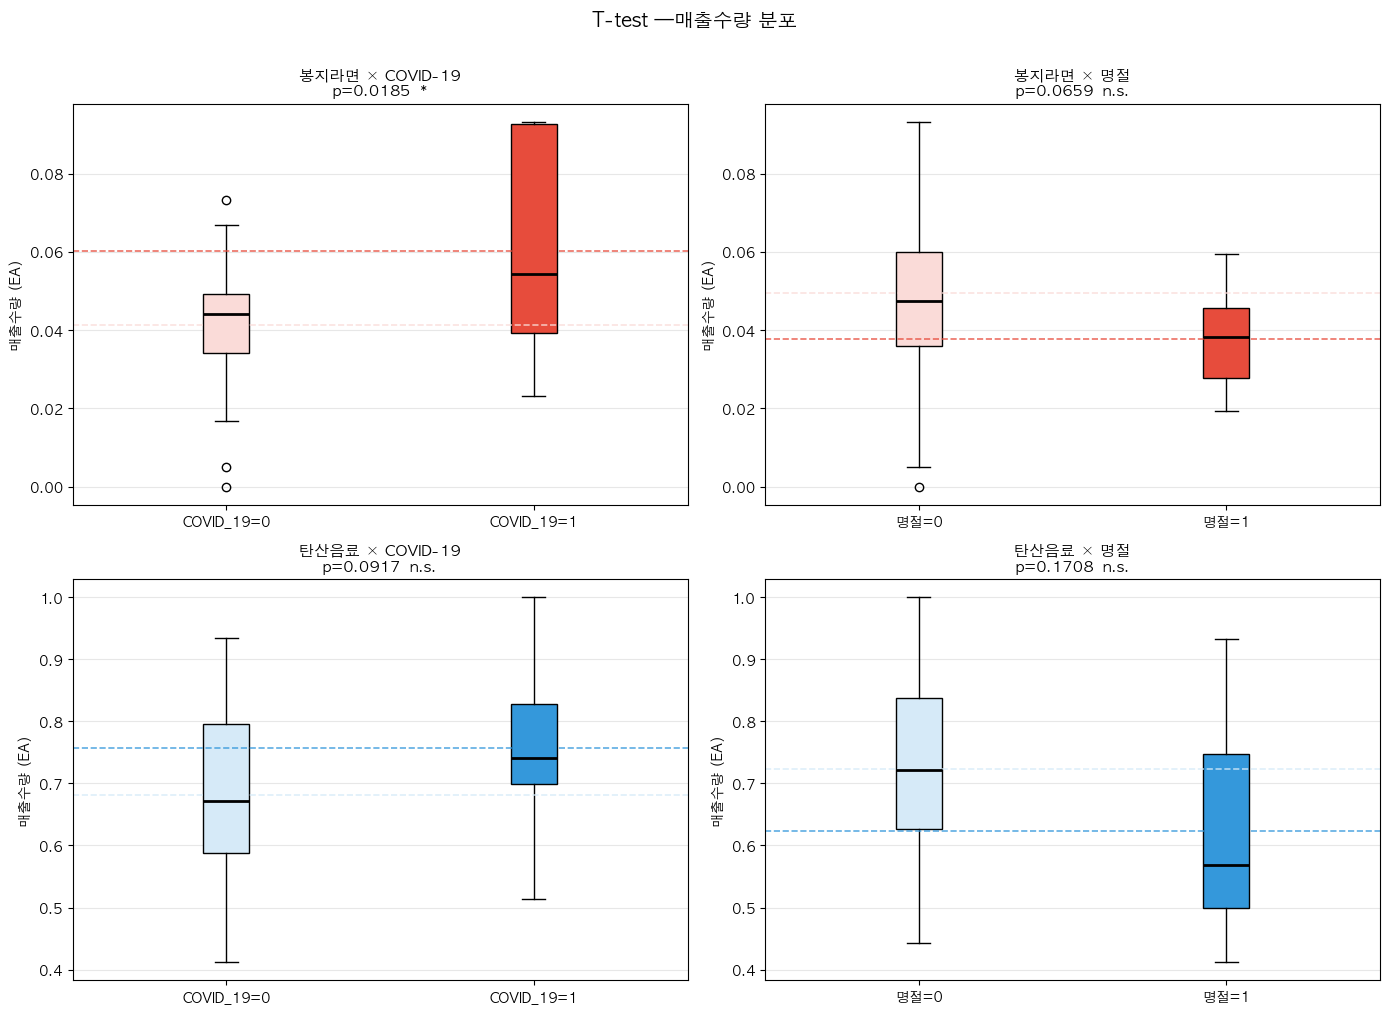

In [8]:
# T-test 박스플롯
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
var_labels = {'COVID_19': 'COVID-19', '명절': '명절'}
colors = {'봉지라면': ['#fadbd8','#e74c3c'], '탄산음료': ['#d6eaf8','#3498db']}

for r, 품목 in enumerate(['봉지라면', '탄산음료']):
    sub = df_final[df_final['품목'] == 품목]
    for c, var in enumerate(binary_vars):
        ax = axes[r][c]
        data_0 = sub[sub[var] == 0]['매출수량'].dropna()
        data_1 = sub[sub[var] == 1]['매출수량'].dropna()

        bp = ax.boxplot([data_0, data_1], patch_artist=True,
                        labels=[f'{var}=0', f'{var}=1'],
                        medianprops=dict(color='black', linewidth=2))
        bp['boxes'][0].set_facecolor(colors[품목][0])
        bp['boxes'][1].set_facecolor(colors[품목][1])

        # p-value 표시
        row = ttest_df[(ttest_df['품목']==품목) & (ttest_df['변수']==var)]
        p_val = row['p-value'].values[0]
        sig   = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'n.s.'))
        ax.set_title(f'{품목} × {var_labels[var]}\np={p_val:.4f}  {sig}',
                     fontsize=11, fontweight='bold')
        ax.set_ylabel('매출수량 (EA)')
        ax.grid(axis='y', alpha=0.3)

        # 평균선
        ax.axhline(data_0.mean(), color=colors[품목][0], linestyle='--', alpha=0.8, linewidth=1.2)
        ax.axhline(data_1.mean(), color=colors[품목][1], linestyle='--', alpha=0.8, linewidth=1.2)

plt.suptitle('T-test —매출수량 분포', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


# 4. 의사결정나무

의사결정나무로 비선형 관계를 파악하려한다

트리가 split 할 때마다 RSS(잔차제곱합) 감소량을 기준으로 변수를 선택하여, Feature Importance를 산출한다.

또한 5-fold 교차검증 R²를 함께 제시하여, 단순히 훈련 데이터에 과적합된 결과가 아닌지 확인한다.
 
중요도가 높을수록 매출수량 예측에 기여하는 변수임을 의미한다.


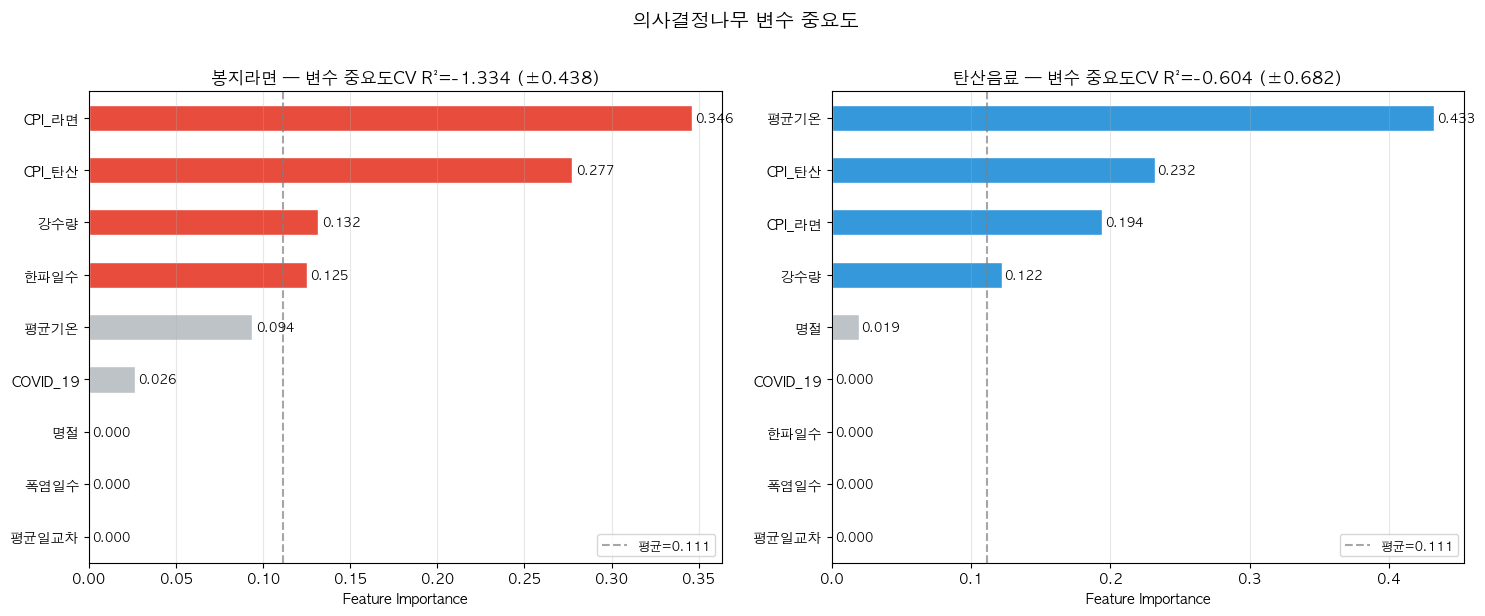


── 봉지라면 변수 중요도 (내림차순) ──
  CPI_라면          0.3459  █████████████████
  CPI_탄산          0.2775  █████████████
  강수량             0.1317  ██████
  한파일수            0.1249  ██████
  평균기온            0.0938  ████
  COVID_19        0.0262  █
  평균일교차           0.0000  
  폭염일수            0.0000  
  명절              0.0000  
  5-fold CV R²: -1.3337 ± 0.4381

── 탄산음료 변수 중요도 (내림차순) ──
  평균기온            0.4326  █████████████████████
  CPI_탄산          0.2318  ███████████
  CPI_라면          0.1943  █████████
  강수량             0.1220  ██████
  명절              0.0193  
  평균일교차           0.0000  
  폭염일수            0.0000  
  한파일수            0.0000  
  COVID_19        0.0000  
  5-fold CV R²: -0.6037 ± 0.6816


In [9]:
feature_cols = [c for c in [ '평균기온', '평균일교차', '강수량',
                             '폭염일수', '한파일수', 'CPI_라면', 'CPI_탄산',
                             'COVID_19', '명절']
                if c in df_final.columns]

dt_results = {}
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (품목, color) in zip(axes, [('봉지라면', '#e74c3c'), ('탄산음료', '#3498db')]):
    sub = df_final[df_final['품목'] == 품목][feature_cols + ['매출수량']].dropna()
    X   = sub[feature_cols]
    y   = sub['매출수량']

    dt = DecisionTreeRegressor(max_depth=4, random_state=42)
    dt.fit(X, y)

    # 교차검증 R²
    cv_scores = cross_val_score(dt, X, y, cv=5, scoring='r2')

    imp = pd.Series(dt.feature_importances_, index=feature_cols).sort_values(ascending=True)
    dt_results[품목] = {'model': dt, 'importance': imp, 'cv_r2': cv_scores}

    # 바 차트
    bar_colors = [color if v >= imp.mean() else '#bdc3c7' for v in imp]
    imp.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='white')
    ax.axvline(imp.mean(), color='gray', linestyle='--', alpha=0.7, label=f'평균={imp.mean():.3f}')
    ax.set_title(f'{품목} — 변수 중요도CV R²={cv_scores.mean():.3f} (±{cv_scores.std():.3f})',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature Importance')
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.3)

    for i, (val, name) in enumerate(zip(imp.values, imp.index)):
        ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('의사결정나무 변수 중요도', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 수치 출력
for 품목 in ['봉지라면', '탄산음료']:
    print(f'\n── {품목} 변수 중요도 (내림차순) ──')
    imp_sorted = dt_results[품목]['importance'].sort_values(ascending=False)
    for var, val in imp_sorted.items():
        bar = '█' * int(val * 50)
        print(f'  {var:<15} {val:.4f}  {bar}')
    cv = dt_results[품목]['cv_r2']
    print(f'  5-fold CV R²: {cv.mean():.4f} ± {cv.std():.4f}')


## 5. 최종 변수 선택 요약

상관분석, T-test, 의사결정나무를 종합하여

2개 이상의 분석에서 유의하다고 선택된 변수를 최종 외생변수로 채택한다.


In [15]:
for 품목 in ['봉지라면', '탄산음료']:
    print(f'\n▶ {품목}')

    # 상관분석: |r| >= 0.3 인 변수
    sig_corr = corr_df[(corr_df['품목']==품목) & (corr_df['r'].abs() >= 0.3)]['변수'].tolist()

    # T-test: p < 0.05 인 이진 변수
    sig_ttest = ttest_df[(ttest_df['품목']==품목) &
                         (ttest_df['p-value'] < 0.05)]['변수'].tolist()

    # 의사결정나무: 평균 이상 중요도 변수
    imp = dt_results[품목]['importance']
    sig_dt = imp[imp >= imp.mean()].sort_values(ascending=False).index.tolist()

    print(f'  상관분석 :  {sig_corr}')
    print(f'  T-test :   {sig_ttest}')
    print(f'  의사결정나무 : {sig_dt}')

    # 2개 이상 분석에서 선택된 변수
    from collections import Counter
    all_selected = sig_corr + sig_ttest + sig_dt
    vote = Counter(all_selected)
    final_vars = [v for v, cnt in vote.most_common() if cnt >= 2]
    print(f' - 최종 선택 변수 : {final_vars}')



▶ 봉지라면
  상관분석 :  ['CPI_라면', 'CPI_탄산']
  T-test :   ['COVID_19']
  의사결정나무 : ['CPI_라면', 'CPI_탄산', '강수량', '한파일수']
 - 최종 선택 변수 : ['CPI_라면', 'CPI_탄산']

▶ 탄산음료
  상관분석 :  ['평균기온', '강수량', '폭염일수', '한파일수', 'CPI_라면', 'CPI_탄산']
  T-test :   []
  의사결정나무 : ['평균기온', 'CPI_탄산', 'CPI_라면', '강수량']
 - 최종 선택 변수 : ['평균기온', '강수량', 'CPI_라면', 'CPI_탄산']


# 5. 회고

- 변수 선택은 단일 기준이 아니라 변수의 유형(연속형/이진형)에 맞는 방법을 선택해야 한다는 것을 직접 경험했다. 
    처음에는 모든 변수를 상관분석으로 처리하려 했지만, COVID_19·명절처럼 이진형 변수는 T-test로 검정하는 것이 통계적으로 더 적절하다는 것을 알게 됐다.
